In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [5]:
df = pd.read_csv('dados_processados.csv')


In [ ]:
# Res: 'H' (casa vence), 'D' (empate), 'A' (fora vence)

df['target'] = df['Res'].map({'H': 0, 'D': 1, 'A': 2})


In [7]:
df['home_goal_ratio'] = df['home_last5_goals'] / (df['home_last5_concede'] + 1e-6)
df['away_goal_ratio'] = df['away_last5_goals'] / (df['away_last5_concede'] + 1e-6)


In [8]:
features = [
    'dif_prob',
    'entropy',
    'home_goal_ratio',
    'away_goal_ratio',
    'home_last5_winrate',
    'away_last5_winrate',
    'home_last5_ppg',
]


In [9]:
df_model = df[features + ['target']].dropna()
print(f'Linhas para modelear: {len(df_model)}')


Linhas para modelear: 5222


In [10]:
X = df_model[features]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['H', 'D', 'A']))


=== RANDOM FOREST ===
Accuracy: 0.4967
              precision    recall  f1-score   support

           H       0.51      0.92      0.66       492
           D       0.36      0.02      0.03       301
           A       0.43      0.23      0.30       252

    accuracy                           0.50      1045
   macro avg       0.43      0.39      0.33      1045
weighted avg       0.45      0.50      0.39      1045



In [12]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== REGRESSÃO LOGÍSTICA ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['H', 'D', 'A']))

=== REGRESSÃO LOGÍSTICA ===
Accuracy: 0.4957
              precision    recall  f1-score   support

           H       0.51      0.92      0.66       492
           D       0.00      0.00      0.00       301
           A       0.40      0.26      0.32       252

    accuracy                           0.50      1045
   macro avg       0.30      0.39      0.33      1045
weighted avg       0.34      0.50      0.39      1045



/home/geovani/anaconda3/envs/map_pass/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


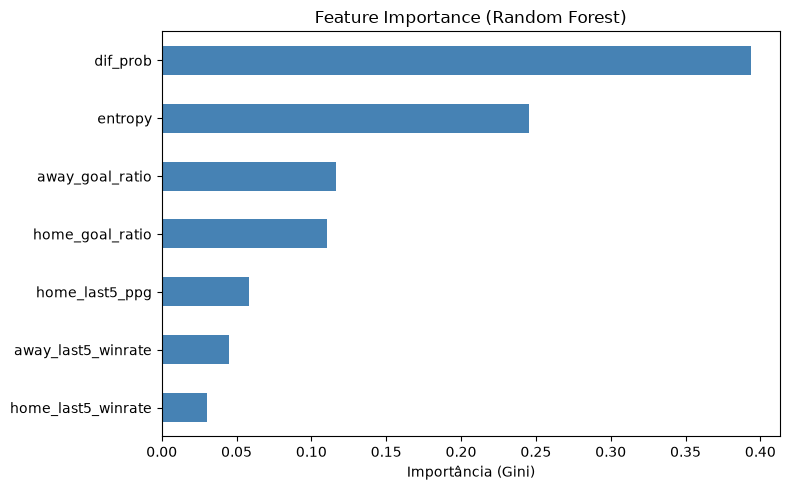

In [15]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()